Autograd - Automatic Gradient
Backpropagation - efficiently evaluate a loss function with respect to the weights of a neural network to reduce the loss

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
import random
%matplotlib inline

In [4]:
def f(x):
    return 3*x**2 - 4*x + 5

In [5]:
f(3.0)

20.0

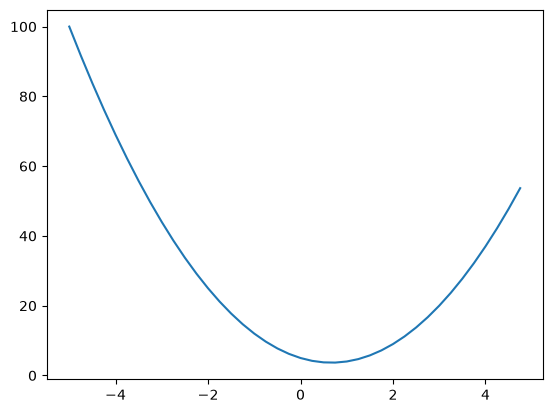

In [8]:
# create set of scalar values to feed in
xs = np.arange(-5, 5, 0.25)
ys = f(xs) # feed values into f(x)
plt.plot(xs, ys)

In [14]:
# what is the derivative of this function at different points (x) of this function?
# lim(h->0)[(f(a + h) - f(a)) / h]
h = 0.00000001
x = 2/3
(f(x + h) - f(x))/h # shows how much the function responds compared to the test h (slope at point x) 
# (smaller h, more accurate slope at that point, derivative evaluation)

0.0

In [15]:
# more complex case, finding derivative 
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [125]:
# now look at derivatives of d with respect to a, b, c
# think: if you change a, how much will that change d? if you change b, how much will that change d? if you change c, how much will that change d?
h = 0.0001

#inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h # bump variable by h, see how d changes
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h) # d2-d1, how much function increased when bumping variable by certain amount, normalize by bump amount h to get slope

d1 4.0
d2 4.0001
slope 0.9999999999976694


In [239]:
# build out value object, scalar object that can be operated on and reports how it came to be (what it's made of (children) and what operator was used (op))

class Value:
    
    # double underscore methods are built-in python methods, like + which is represented as __add__
    
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0 # derivative of final value with respect to current value
        self._backward = lambda: None # empty function to be defined for piece of chain rule on each value for backpropagation for each type of operation
        self._prev = set(_children) # save what each value is made up of
        self._op = _op # save the operator used to get the value
        self.label = label
        
    def __repr__(self): # repr provides a way to print out information, not just the memory spot
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other) # if "other" is not a value, wrap it in value
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        
        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
            
        return out
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supports int/float powers for now"
        out = Value(self.data**other, (self, ), f'**{other}')
        
        def _backward():
            self.grad += other * (self.data**(other -1)) * out.grad # d/dx x^n = nx^n-1
        out._backward = _backward
        return out
    
    def __rmul__(self, other): # other * self
        return self * other
    
    def __radd__(self, other): # other + self
        return self + other
    
    def __truediv__(self, other): # self / other
        return self * other**-1
    
    def __neg__(self): # -self
        return self * -1
    
    def __sub__(self, other): # self - other
        return self + (-other)
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        
        def _backward():
            self.grad += (1 - t**2) * out.grad # chained through local derivative
        out._backward = _backward
        
        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')
        
        def _backward():
            self.grad += out.data * out.grad # exp is its own derivative
        out._backward = _backward
        
        return out
    
    def backward(self):

        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self) # build topological order

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

# must ACCUMULATE gradients, not just set, when evaluating. that way, if you use the same variable more than once, its gradient will add to its own. 

In [179]:
# graph out steps taken to get to final value
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot


In [209]:
a = Value(4.0)
b = Value(2.0)
c = a / b
print(c)

Value(data=2.0)


Use chain rule to figure out each node's impact on final node:

ex: z depends on x depends on y

so:
dz/dx = dz/dy * dy/dx (product of preceeding derivatives)

deriv of L wrt previous nodes, recursive propagation of chain rule backwards through operation graph

In [210]:
# tanh will be our activation function [dot] (weights * inputs)
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1 * w1; x1w1.label='x1*w1'
x2w2 = x2 * w2; x2w2.label='x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label='n'

# apply activation function:
o = n.tanh(); o.label='o'

o.backward()

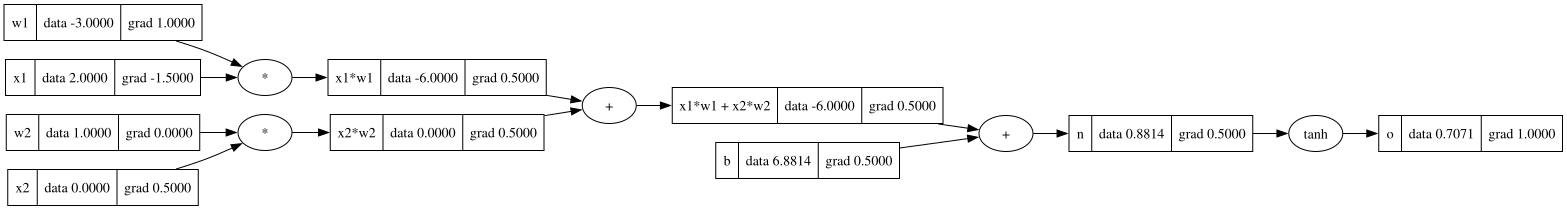

In [211]:
draw_dot(o)

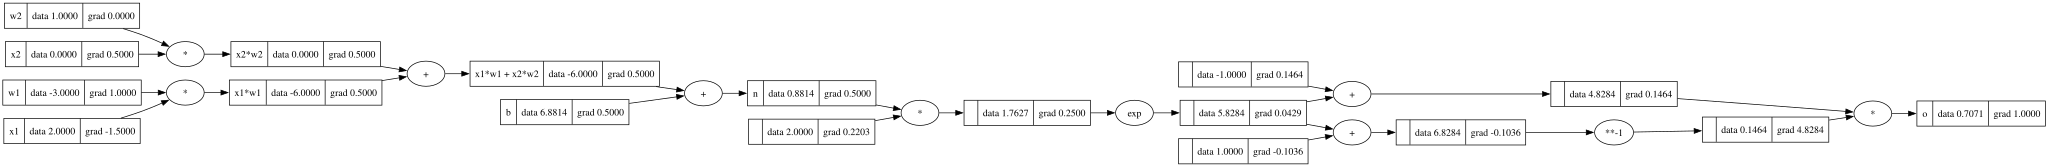

In [214]:
# tanh will be our activation function [dot] (weights * inputs)
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1 * w1; x1w1.label='x1*w1'
x2w2 = x2 * w2; x2w2.label='x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label='n'

# apply tanh with parts (e^2x - 1)/(e^2x + 1)
e = (2*n).exp()
o = (e - 1) / (e + 1)
# ----

o.label='o'

o.backward()

draw_dot(o)

In [217]:
import torch

In [ ]:
# micrograd is based on scalars, all inputs have to be scalar values. pytorch is based on tensors, n-dimensional arrays of scalars

# inputs

x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item()) #.item returns element from tensor of one element
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [286]:
# building out a neural net library (multi-layer perceptron) in micrograd

class Neuron:
    
    #constructor - initialize neuron with random weights and biases between -1 and 1
    def __init__(self, nin): #nin being number of inputs
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
        
    def __call__(self, x): # __call__ -> activates when f(x) notation is used
        # w * x + b (where w * x is a dot product)
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b) # perform w * x + b op over all w and x pairs
        out = act.tanh() # squish between -1,1
        return out
    
    def parameters(self):
        return self.w + [self.b] # return all computed weights and biases as a list
    
class Layer: # define a layer of neurons
    
    def __init__(self, nin, nout): # num inputs per neuron, num neurons to create on layer
        self.neurons = [Neuron(nin) for _ in range(nout)]
        
    def __call__(self, x):
        outs = [n(x) for n in self.neurons] # evaluate input per neuron
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
        # v
        # params = [] # create list of parameters for layers
        # for neuron in self.neurons:
        #    ps = neuron.parameters() # for each neuron, get its parameters, then...
        #    params.extend(ps) # ...add them to the params list for layer
        # return params

class MLP: # multi-layer perceptron, a "stack" of layers
    
    def __init__(self, nin, nouts): # nouts is a list of outs, defines wanted size of all layers in mlp
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()] # return p for current layer which is all parameters in layer being computed

#WANT:
# 3 inputs -> layer of 4 -> layer of 4 -> 1 output





In [ ]:
n = MLP(3, [4, 4, 1]) # 3 inputs into (list of)2 layers of four and one output (final element in list, final layer, is 1 output)

Value(data=0.08925547658448509)

In [382]:
# dataset

# inputs
xs = [
  [2.0, 3.0, -1.0], #example 1
  [3.0, -1.0, 0.5], #example 2
  [0.5, 1.0, 1.0], #example 3
  [1.0, 1.0, -1.0], #example 4
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets



In [ ]:
# training loop - gradient descent

for k in range(20):
    
    # forward pass
    ypred = [n(x) for x in xs] # predict
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred)) # evaluate loss using MSE, CEL (cross-entropy loss) is better
    
    # backward pass
    for p in n.parameters():
        p.grad = 0.0 # zero out grad so gradients do not accumulate over passes and the backward pass actually properly accumulates the loss derivs
    loss.backward()
    
    # update
    for p in n.parameters(): # adjust all parameters in the opposite direction of the gradient (go down, not up, minimize loss)
        p.data += -0.05 * p.grad # updates are different in other types of training loops.
        
    print(k, loss.data)


0 0.005279522201080583
1 0.005212246580858111
2 0.005146637451085494
3 0.005082634057646443
4 0.005020178552863722
5 0.004959215824188116
6 0.004899693334841467
7 0.004841560975452698
8 0.004784770925813916
9 0.004729277525960755
10 0.0046750371558529225
11 0.004622008122993499
12 0.004570150557383499
13 0.00451942631326002
14 0.004469798877112584
15 0.004421233281515775
16 0.004373696024353646
17 0.004327154993047248
18 0.004281579393427831
19 0.004236939682926916


In [388]:
ypred

[Value(data=0.9712675164705425),
 Value(data=-0.9723196233977315),
 Value(data=-0.9616060802101553),
 Value(data=0.9657788406467004)]

In [389]:
n.parameters()

[Value(data=-0.4651898155910504),
 Value(data=0.859283889216347),
 Value(data=0.4066634887317615),
 Value(data=-0.5862971389877444),
 Value(data=-0.8372891644259434),
 Value(data=0.5703870408505045),
 Value(data=-0.8121991959519459),
 Value(data=0.2946674745439974),
 Value(data=-0.3537606204080859),
 Value(data=0.5974584236280867),
 Value(data=-0.8074438460472848),
 Value(data=-0.38180674771429335),
 Value(data=0.7508985019574596),
 Value(data=0.4529328197180789),
 Value(data=0.8560501488544623),
 Value(data=0.16367930095771985),
 Value(data=-0.5297295992322375),
 Value(data=0.7393401307097031),
 Value(data=0.6620166789874042),
 Value(data=0.5790326948963994),
 Value(data=-0.8550667149874759),
 Value(data=0.08900024233982017),
 Value(data=0.6144656114180513),
 Value(data=0.9272961259233343),
 Value(data=-0.6120933632389366),
 Value(data=0.7771404426548791),
 Value(data=0.8282184212605691),
 Value(data=-0.7204144477647643),
 Value(data=-1.200541612948184),
 Value(data=-0.592716312626546